### Data Augmentation

 We have a lot of data but mainly it concentrates on the forward, right an unknown. Here we are trying to even out. We will use rotation or mirroring(vertial or horizontal flip) to create backward data from forward and right etc. We might also reduce the amount of unknow data accordingly.



Image counts:
forward  : 7800
right    : 1800
unknown  : 9800
left     : 0
backward : 0


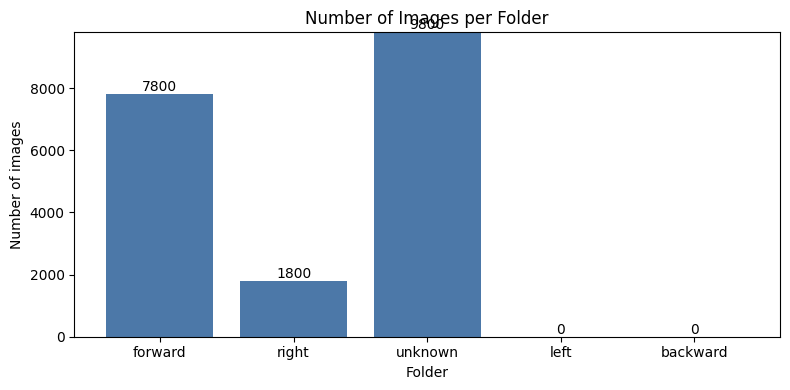

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

ROOT_DIR = Path("Data_to_augment")  # same level as your script, or replace with an absolute path

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff", ".webp"}

def count_images_in_dir(dir_path: Path) -> int:
    if not dir_path.exists() or not dir_path.is_dir():
        return 0
    return sum(
        1
        for p in dir_path.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    )

categories = ["forward", "right", "unknown", "left", "backward"]
counts = {cat: count_images_in_dir(ROOT_DIR / cat) for cat in categories}

print("Image counts:")
for cat in categories:
    print(f"{cat:9s}: {counts[cat]}")

# Plot
plt.figure(figsize=(8, 4))
values = [counts[c] for c in categories]
bars = plt.bar(categories, values, color=["#4C78A8"] * len(categories))

plt.title("Number of Images per Folder")
plt.xlabel("Folder")
plt.ylabel("Number of images")
plt.ylim(0, max(values) + 1 if max(values) > 0 else 1)

# Label bars
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val, str(val),
             ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

### Going to write a code for renaming the images like <folder_name><101>

In [ ]:
from pathlib import Path

ROOT_DIR = Path("Data_to_augment")  

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff", ".webp"}

# Folders to process
folders = ["forward", "right", "unknown"]

START_INDEX = 101  # naming starts at 101 
DRY_RUN = True     # set to False to actually rename

def is_image(p: Path) -> bool:
    return p.is_file() and p.suffix.lower() in IMAGE_EXTS

for folder in folders:
    folder_path = ROOT_DIR / folder
    if not folder_path.exists():
        print(f"Skipping missing folder: {folder_path}")
        continue

    # Collect images non-recursive
    images = sorted([p for p in folder_path.iterdir() if is_image(p)])

    print(f"\nFolder: {folder_path}  |  images found: {len(images)}")

    # First compute all rename operations safely 
    planned = []
    used_targets = set()

    for i, src in enumerate(images, start=START_INDEX):
        new_name = f"{folder}_{i}{src.suffix.lower()}"  # keep extension
        dst = folder_path / new_name

        # Handle potential collisions (e.g., file already exists)
        if dst.exists() or dst in used_targets:
            # Try adding an incrementing suffix until free
            k = 1
            while True:
                dst = folder_path / f"{folder}_{i}_{k}{src.suffix.lower()}"
                if not dst.exists() and dst not in used_targets:
                    break
                k += 1

        planned.append((src, dst))
        used_targets.add(dst)

    # Two phase rename using temporary names to avoid name clashes on Windows
    temp_pairs = []
    for n, (src, dst) in enumerate(planned):
        tmp = src.with_name(f".__tmp__{folder}_{n}__{src.suffix.lower()}")
        temp_pairs.append((src, tmp, dst))

    # Show plan
    for src, tmp, dst in temp_pairs[:10]:
        print(f"  {src.name}  ->  {dst.name}")
    if len(temp_pairs) > 10:
        print(f"  ... ({len(temp_pairs) - 10} more)")

    if DRY_RUN:
        print("DRY_RUN=True so no files were renamed. Set DRY_RUN=False to apply.")
        continue

    # Apply renames from src to tmp
    for src, tmp, _dst in temp_pairs:
        src.rename(tmp)

    # Apply rename from tmp to final
    for _src, tmp, dst in temp_pairs:
        tmp.rename(dst)

    print("Renaming complete.")


Folder: Data_to_augment/forward  |  images found: 7800
  frame_00_01_0001.png  ->  forward_101.png
  frame_00_01_0002.png  ->  forward_102.png
  frame_00_01_0003.png  ->  forward_103.png
  frame_00_01_0004.png  ->  forward_104.png
  frame_00_01_0005.png  ->  forward_105.png
  frame_00_01_0006.png  ->  forward_106.png
  frame_00_01_0007.png  ->  forward_107.png
  frame_00_01_0008.png  ->  forward_108.png
  frame_00_01_0009.png  ->  forward_109.png
  frame_00_01_0010.png  ->  forward_110.png
  ... (7790 more)
Renaming complete.

Folder: Data_to_augment/right  |  images found: 1800
  frame_01_05_0001.png  ->  right_101.png
  frame_01_05_0002.png  ->  right_102.png
  frame_01_05_0003.png  ->  right_103.png
  frame_01_05_0004.png  ->  right_104.png
  frame_01_05_0005.png  ->  right_105.png
  frame_01_05_0006.png  ->  right_106.png
  frame_01_05_0007.png  ->  right_107.png
  frame_01_05_0008.png  ->  right_108.png
  frame_01_05_0009.png  ->  right_109.png
  frame_01_05_0010.png  ->  right_1

In [4]:
pip install pillow

Note: you may need to restart the kernel to use updated packages.


### Code to augment right class images to left(augmentation used is horizontal flip)

In [ ]:
from __future__ import annotations

from pathlib import Path
from PIL import Image, ImageOps

# ---------------- CONFIG ----------------
ROOT_DIR = Path("Data_to_augment")
RIGHT_DIR = ROOT_DIR / "right"
LEFT_DIR = ROOT_DIR / "left"

# naming
START_INDEX = 101
OUTPUT_EXT = ".png"   # change to ".jpg" if you prefer JPG output
DRY_RUN = True        # set False to actually write files

# which files are treated as images
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

# ---------------- HELPERS ----------------
def list_images(folder: Path):
    return sorted(
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    )

def ensure_left_dir():
    if LEFT_DIR.exists():
        return
    if DRY_RUN:
        print(f"[DRY_RUN] Would create folder: {LEFT_DIR}")
    else:
        LEFT_DIR.mkdir(parents=True, exist_ok=True)

def save_mirrored(src_path: Path, dst_path: Path):
    if DRY_RUN:
        print(f"[DRY_RUN] {src_path.name} -> {dst_path.name}")
        return

    with Image.open(src_path) as im:
        # Keep consistent mode; PNG works well for grayscale too
        # If you want to preserve grayscale, remove the convert("RGB")
        im2 = im.convert("RGB")
        out = ImageOps.mirror(im2)  # horizontal flip (left-right)
        out.save(dst_path)

# ---------------- MAIN ----------------
def main():
    if not RIGHT_DIR.exists():
        raise FileNotFoundError(f"Missing folder: {RIGHT_DIR}")

    ensure_left_dir()

    right_images = list_images(RIGHT_DIR)
    print(f"Found {len(right_images)} images in: {RIGHT_DIR}")

    # If left already has files, we continue numbering after the last left_XXX
    existing_left = list_images(LEFT_DIR) if LEFT_DIR.exists() else []
    if existing_left:
        # try to parse numbers from names like left_101.png
        nums = []
        for p in existing_left:
            stem = p.stem  # e.g., left_101
            parts = stem.split("_")
            if len(parts) >= 2 and parts[0].lower() == "left":
                try:
                    nums.append(int(parts[1]))
                except ValueError:
                    pass
        next_index = (max(nums) + 1) if nums else START_INDEX
    else:
        next_index = START_INDEX

    print(f"Left output folder: {LEFT_DIR}")
    print(f"Starting index: {next_index}")
    print(f"Output extension: {OUTPUT_EXT}")
    print(f"DRY_RUN: {DRY_RUN}\n")

    count_written = 0
    for src in right_images:
        dst = LEFT_DIR / f"left_{next_index}{OUTPUT_EXT}"
        save_mirrored(src, dst)
        next_index += 1
        count_written += 1

    print(f"\nDone. {'Would write' if DRY_RUN else 'Wrote'} {count_written} left images.")

if __name__ == "__main__":
    main()

Found 1800 images in: Data_to_augment/right
Left output folder: Data_to_augment/left
Starting index: 101
Output extension: .png
DRY_RUN: False


Done. Wrote 1800 left images.


### Code for augmenting right class creating backward class ( augmentation used is rotation)

In [ ]:
from __future__ import annotations

from pathlib import Path
from PIL import Image

# ---------------- CONFIG ----------------
ROOT_DIR = Path("Data_to_augment")
RIGHT_DIR = ROOT_DIR / "right"
BACKWARD_DIR = ROOT_DIR / "backward"

START_INDEX = 101
OUTPUT_EXT = ".png"   # choose ".jpg" if you prefer
DRY_RUN = True       # set to False to actually write files

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

# ---------------- HELPERS ----------------
def list_images(folder: Path):
    return sorted(
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    )

def ensure_backward_dir():
    if BACKWARD_DIR.exists():
        return
    if DRY_RUN:
        print(f"[DRY_RUN] Would create folder: {BACKWARD_DIR}")
    else:
        BACKWARD_DIR.mkdir(parents=True, exist_ok=True)

def rotate_90_cw(im: Image.Image) -> Image.Image:
    # exact 90 degrees clockwise
    return im.transpose(Image.Transpose.ROTATE_270)

def save_rotated(src_path: Path, dst_path: Path):
    if DRY_RUN:
        print(f"[DRY_RUN] {src_path.name} -> {dst_path.name}")
        return
    with Image.open(src_path) as im:
        out = rotate_90_cw(im)
        # Keep consistent save output; convert to RGB for JPG/PNG compatibility
        out = out.convert("RGB")
        out.save(dst_path)

def next_start_index(existing_files) -> int:
    """
    If backward folder already has backward_<num> files, continue numbering after max.
    Otherwise start at START_INDEX.
    """
    nums = []
    for p in existing_files:
        stem = p.stem  # e.g., backward_123
        parts = stem.split("_")
        if len(parts) >= 2 and parts[0].lower() == "backward":
            try:
                nums.append(int(parts[1]))
            except ValueError:
                pass
    return (max(nums) + 1) if nums else START_INDEX

# ---------------- MAIN ----------------
def main():
    if not RIGHT_DIR.exists():
        raise FileNotFoundError(f"Missing folder: {RIGHT_DIR}")

    ensure_backward_dir()

    right_images = list_images(RIGHT_DIR)
    print(f"Found {len(right_images)} images in: {RIGHT_DIR}")

    existing_backward = list_images(BACKWARD_DIR) if BACKWARD_DIR.exists() else []
    start = next_start_index(existing_backward)

    print(f"Backward output folder: {BACKWARD_DIR}")
    print(f"Starting index: {start}")
    print(f"Output extension: {OUTPUT_EXT}")
    print(f"DRY_RUN: {DRY_RUN}\n")

    idx = start
    for src in right_images:
        dst = BACKWARD_DIR / f"backward_{idx}{OUTPUT_EXT}"
        save_rotated(src, dst)
        idx += 1

    print(f"\nDone. {'Would write' if DRY_RUN else 'Wrote'} {len(right_images)} backward images.")

if __name__ == "__main__":
    main()

Found 1800 images in: Data_to_augment/right
Backward output folder: Data_to_augment/backward
Starting index: 101
Output extension: .png
DRY_RUN: False


Done. Wrote 1800 backward images.


### Code for augmenting forward class and moving them to right class

In [ ]:
from __future__ import annotations

from pathlib import Path
from PIL import Image

# ---------------- CONFIG ----------------
ROOT_DIR = Path("Data_to_augment")
FORWARD_DIR = ROOT_DIR / "forward"
RIGHT_DIR = ROOT_DIR / "right"

START_INDEX = 1901          # you requested right_1901 as the first augmented name
OUTPUT_EXT = ".png"         # change to ".jpg" if you prefer
DRY_RUN = True              # set to False to actually write files

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

# ---------------- HELPERS ----------------
def list_images(folder: Path):
    if not folder.exists():
        return []
    return sorted(
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    )

def ensure_right_dir():
    if RIGHT_DIR.exists():
        return
    if DRY_RUN:
        print(f"[DRY_RUN] Would create folder: {RIGHT_DIR}")
    else:
        RIGHT_DIR.mkdir(parents=True, exist_ok=True)

def rotate_90_cw(im: Image.Image) -> Image.Image:
    # exact 90 degrees clockwise
    return im.transpose(Image.Transpose.ROTATE_270)

def next_start_index(existing_files) -> int:
    """
    Continue numbering after max right_<num> if it is >= START_INDEX.
    Otherwise start at START_INDEX.
    """
    nums = []
    for p in existing_files:
        stem = p.stem  # e.g., right_1234
        parts = stem.split("_")
        if len(parts) >= 2 and parts[0].lower() == "right":
            try:
                nums.append(int(parts[1]))
            except ValueError:
                pass
    if not nums:
        return START_INDEX
    return max(START_INDEX, max(nums) + 1)

def save_rotated(src_path: Path, dst_path: Path):
    if DRY_RUN:
        print(f"[DRY_RUN] {src_path.name} -> {dst_path.name}")
        return
    with Image.open(src_path) as im:
        out = rotate_90_cw(im).convert("RGB")
        out.save(dst_path)

# ---------------- MAIN ----------------
def main():
    if not FORWARD_DIR.exists():
        raise FileNotFoundError(f"Missing folder: {FORWARD_DIR}")

    ensure_right_dir()

    forward_images = list_images(FORWARD_DIR)
    if not forward_images:
        raise RuntimeError(f"No images found in: {FORWARD_DIR}")

    existing_right = list_images(RIGHT_DIR)
    start = next_start_index(existing_right)

    print(f"Found {len(forward_images)} images in: {FORWARD_DIR}")
    print(f"Right output folder: {RIGHT_DIR}")
    print(f"Starting index: {start}")
    print(f"Output extension: {OUTPUT_EXT}")
    print(f"DRY_RUN: {DRY_RUN}\n")

    idx = start
    for src in forward_images:
        dst = RIGHT_DIR / f"right_{idx}{OUTPUT_EXT}"
        save_rotated(src, dst)
        idx += 1

    print(f"\nDone. {'Would write' if DRY_RUN else 'Wrote'} {len(forward_images)} augmented right images.")
    print(f"Last index used: {idx - 1}")

if __name__ == "__main__":
    main()

Found 7800 images in: Data_to_augment/forward
Right output folder: Data_to_augment/right
Starting index: 1901
Output extension: .png
DRY_RUN: False


Done. Wrote 7800 augmented right images.
Last index used: 9700


### Code for augmenting forward class and moving them to left class

In [ ]:
from __future__ import annotations

from pathlib import Path
from PIL import Image

# ---------------- CONFIG ----------------
ROOT_DIR = Path("Data_to_augment")
FORWARD_DIR = ROOT_DIR / "forward"
LEFT_DIR = ROOT_DIR / "left"

START_INDEX = 1901          # you requested left_1901 as the first augmented name
OUTPUT_EXT = ".png"         # change to ".jpg" if you prefer
DRY_RUN = True              # set to False to actually write files

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

# ---------------- HELPERS ----------------
def list_images(folder: Path):
    if not folder.exists():
        return []
    return sorted(
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    )

def ensure_left_dir():
    if LEFT_DIR.exists():
        return
    if DRY_RUN:
        print(f"[DRY_RUN] Would create folder: {LEFT_DIR}")
    else:
        LEFT_DIR.mkdir(parents=True, exist_ok=True)

def rotate_90_ccw(im: Image.Image) -> Image.Image:
    # exact 90 degrees anti-clockwise (counter-clockwise)
    return im.transpose(Image.Transpose.ROTATE_90)

def next_start_index(existing_files) -> int:
    """
    Continue numbering after max left_<num> if it is >= START_INDEX.
    Otherwise start at START_INDEX.
    """
    nums = []
    for p in existing_files:
        stem = p.stem  # e.g., left_1234
        parts = stem.split("_")
        if len(parts) >= 2 and parts[0].lower() == "left":
            try:
                nums.append(int(parts[1]))
            except ValueError:
                pass
    if not nums:
        return START_INDEX
    return max(START_INDEX, max(nums) + 1)

def save_rotated(src_path: Path, dst_path: Path):
    if DRY_RUN:
        print(f"[DRY_RUN] {src_path.name} -> {dst_path.name}")
        return
    with Image.open(src_path) as im:
        out = rotate_90_ccw(im).convert("RGB")
        out.save(dst_path)

# ---------------- MAIN ----------------
def main():
    if not FORWARD_DIR.exists():
        raise FileNotFoundError(f"Missing folder: {FORWARD_DIR}")

    ensure_left_dir()

    forward_images = list_images(FORWARD_DIR)
    if not forward_images:
        raise RuntimeError(f"No images found in: {FORWARD_DIR}")

    existing_left = list_images(LEFT_DIR)
    start = next_start_index(existing_left)

    print(f"Found {len(forward_images)} images in: {FORWARD_DIR}")
    print(f"Left output folder: {LEFT_DIR}")
    print(f"Starting index: {start}")
    print(f"Output extension: {OUTPUT_EXT}")
    print(f"DRY_RUN: {DRY_RUN}\n")

    idx = start
    for src in forward_images:
        dst = LEFT_DIR / f"left_{idx}{OUTPUT_EXT}"
        save_rotated(src, dst)
        idx += 1

    print(f"\nDone. {'Would write' if DRY_RUN else 'Wrote'} {len(forward_images)} augmented left images.")
    print(f"Last index used: {idx - 1}")

if __name__ == "__main__":
    main()

Found 7800 images in: Data_to_augment/forward
Left output folder: Data_to_augment/left
Starting index: 1901
Output extension: .png
DRY_RUN: False


Done. Wrote 7800 augmented left images.
Last index used: 9700


### Code for augmenting forward class and moving them to backward class

In [ ]:
from __future__ import annotations

from pathlib import Path
from PIL import Image, ImageOps

# ---------------- CONFIG ----------------
ROOT_DIR = Path("Data_to_augment")
FORWARD_DIR = ROOT_DIR / "forward"
BACKWARD_DIR = ROOT_DIR / "backward"

START_INDEX = 1901          # you requested backward_1901 as the first augmented name
OUTPUT_EXT = ".png"         # change to ".jpg" if you prefer
DRY_RUN = True              # set to False to actually write files

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

# ---------------- HELPERS ----------------
def list_images(folder: Path):
    if not folder.exists():
        return []
    return sorted(
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    )

def ensure_backward_dir():
    if BACKWARD_DIR.exists():
        return
    if DRY_RUN:
        print(f"[DRY_RUN] Would create folder: {BACKWARD_DIR}")
    else:
        BACKWARD_DIR.mkdir(parents=True, exist_ok=True)

def vertical_mirror(im: Image.Image) -> Image.Image:
    # vertical flip (top <-> bottom)
    return ImageOps.flip(im)

def next_start_index(existing_files) -> int:
    """
    Continue numbering after max backward_<num> if it is >= START_INDEX.
    Otherwise start at START_INDEX.
    """
    nums = []
    for p in existing_files:
        stem = p.stem  # e.g., backward_1234
        parts = stem.split("_")
        if len(parts) >= 2 and parts[0].lower() == "backward":
            try:
                nums.append(int(parts[1]))
            except ValueError:
                pass
    if not nums:
        return START_INDEX
    return max(START_INDEX, max(nums) + 1)

def save_flipped(src_path: Path, dst_path: Path):
    if DRY_RUN:
        print(f"[DRY_RUN] {src_path.name} -> {dst_path.name}")
        return
    with Image.open(src_path) as im:
        out = vertical_mirror(im).convert("RGB")
        out.save(dst_path)

# ---------------- MAIN ----------------
def main():
    if not FORWARD_DIR.exists():
        raise FileNotFoundError(f"Missing folder: {FORWARD_DIR}")

    ensure_backward_dir()

    forward_images = list_images(FORWARD_DIR)
    if not forward_images:
        raise RuntimeError(f"No images found in: {FORWARD_DIR}")

    existing_backward = list_images(BACKWARD_DIR)
    start = next_start_index(existing_backward)

    print(f"Found {len(forward_images)} images in: {FORWARD_DIR}")
    print(f"Backward output folder: {BACKWARD_DIR}")
    print(f"Starting index: {start}")
    print(f"Output extension: {OUTPUT_EXT}")
    print(f"DRY_RUN: {DRY_RUN}\n")

    idx = start
    for src in forward_images:
        dst = BACKWARD_DIR / f"backward_{idx}{OUTPUT_EXT}"
        save_flipped(src, dst)
        idx += 1

    print(f"\nDone. {'Would write' if DRY_RUN else 'Wrote'} {len(forward_images)} augmented backward images.")
    print(f"Last index used: {idx - 1}")

if __name__ == "__main__":
    main()

Found 7800 images in: Data_to_augment/forward
Backward output folder: Data_to_augment/backward
Starting index: 1901
Output extension: .png
DRY_RUN: False


Done. Wrote 7800 augmented backward images.
Last index used: 9700


### I had forgotten to augment right for forward and add them so I copied the current right and saved it somewhere and then replaced the right here with the old sorted data right. Now code for augment right and add to forward.

In [ ]:
from __future__ import annotations

from pathlib import Path
from PIL import Image

# ---------------- CONFIG ----------------
ROOT_DIR = Path("Data_to_augment")
RIGHT_DIR = ROOT_DIR / "right"
FORWARD_DIR = ROOT_DIR / "forward"

START_INDEX = 7901          # you requested starting number 7901
OUTPUT_EXT = ".png"         # change to ".jpg" if you prefer
DRY_RUN = True              # set to False to actually write files

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

# ---------------- HELPERS ----------------
def list_images(folder: Path):
    if not folder.exists():
        return []
    return sorted(
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    )

def ensure_forward_dir():
    if FORWARD_DIR.exists():
        return
    if DRY_RUN:
        print(f"[DRY_RUN] Would create folder: {FORWARD_DIR}")
    else:
        FORWARD_DIR.mkdir(parents=True, exist_ok=True)

def rotate_90_ccw(im: Image.Image) -> Image.Image:
    # exact 90 degrees anti-clockwise (counter-clockwise)
    return im.transpose(Image.Transpose.ROTATE_90)

def next_start_index(existing_files) -> int:
    """
    Continue numbering after max forward_<num> if it is >= START_INDEX.
    Otherwise start at START_INDEX.
    """
    nums = []
    for p in existing_files:
        stem = p.stem  # e.g., forward_8001
        parts = stem.split("_")
        if len(parts) >= 2 and parts[0].lower() == "forward":
            try:
                nums.append(int(parts[1]))
            except ValueError:
                pass
    if not nums:
        return START_INDEX
    return max(START_INDEX, max(nums) + 1)

def save_rotated(src_path: Path, dst_path: Path):
    if DRY_RUN:
        print(f"[DRY_RUN] {src_path.name} -> {dst_path.name}")
        return
    with Image.open(src_path) as im:
        out = rotate_90_ccw(im).convert("RGB")
        out.save(dst_path)

# ---------------- MAIN ----------------
def main():
    if not RIGHT_DIR.exists():
        raise FileNotFoundError(f"Missing folder: {RIGHT_DIR}")

    ensure_forward_dir()

    right_images = list_images(RIGHT_DIR)
    if not right_images:
        raise RuntimeError(f"No images found in: {RIGHT_DIR}")

    existing_forward = list_images(FORWARD_DIR)
    start = next_start_index(existing_forward)

    print(f"Found {len(right_images)} images in: {RIGHT_DIR}")
    print(f"Forward output folder: {FORWARD_DIR}")
    print(f"Starting index: {start}")
    print(f"Output extension: {OUTPUT_EXT}")
    print(f"DRY_RUN: {DRY_RUN}\n")

    idx = start
    for src in right_images:
        dst = FORWARD_DIR / f"forward_{idx}{OUTPUT_EXT}"
        save_rotated(src, dst)
        idx += 1

    print(f"\nDone. {'Would write' if DRY_RUN else 'Wrote'} {len(right_images)} augmented forward images.")
    print(f"Last index used: {idx - 1}")

if __name__ == "__main__":
    main()

Found 1800 images in: Data_to_augment/right
Forward output folder: Data_to_augment/forward
Starting index: 7901
Output extension: .png
DRY_RUN: False


Done. Wrote 1800 augmented forward images.
Last index used: 9700


## Now we have 9600 images with 5 variations in each class

### code for randomizing and moving 2500 images of right and left class to augmented data while renaming as well

In [ ]:
from __future__ import annotations

import random
import shutil
from pathlib import Path

# --------------- CONFIG ---------------
SOURCE_ROOT = Path("Data_to_augment")
DEST_ROOT = Path("augmented_data")

CLASSES = ["right", "left", "forward", "backward"]
N_PER_CLASS = 2500

RANDOM_SEED = 42
DRY_RUN = True  # set to False to actually copy files

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

START_INDEX = 101
OUTPUT_EXT = ".png"  # destination extension (all copied images will be saved as PNG)

# --------------- HELPERS ---------------
def list_images(folder: Path) -> list[Path]:
    if not folder.exists():
        return []
    return sorted(
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    )

def ensure_dir(p: Path) -> None:
    if DRY_RUN:
        if not p.exists():
            print(f"[DRY_RUN] Would create folder: {p}")
        return
    p.mkdir(parents=True, exist_ok=True)

def copy_and_rename_as_png(src: Path, dst: Path) -> None:
    """
    Copies image content to dst as PNG.
    This avoids mixed extensions in the destination and guarantees sequential naming.
    """
    if DRY_RUN:
        print(f"[DRY_RUN] COPY {src} -> {dst}")
        return

    # Use binary copy if source is already png and you want pure copy:
    # but here we standardize to PNG output, so open+save.
    from PIL import Image  # local import to keep dependency obvious
    with Image.open(src) as im:
        im.save(dst, format="PNG")

# --------------- MAIN ---------------
def main() -> None:
    random.seed(RANDOM_SEED)

    # Create destination folders
    ensure_dir(DEST_ROOT)
    for cls in CLASSES:
        ensure_dir(DEST_ROOT / cls)

    for cls in CLASSES:
        src_dir = SOURCE_ROOT / cls
        dst_dir = DEST_ROOT / cls

        if not src_dir.exists():
            raise FileNotFoundError(f"Missing source folder: {src_dir}")

        images = list_images(src_dir)
        if len(images) < N_PER_CLASS:
            raise ValueError(
                f"Not enough images in {src_dir}. Found {len(images)}, need {N_PER_CLASS}."
            )

        chosen = random.sample(images, k=N_PER_CLASS)

        print(f"\nClass '{cls}': selecting {N_PER_CLASS} of {len(images)} images")
        print(f"Renaming to: {cls}_{START_INDEX}{OUTPUT_EXT} ... {cls}_{START_INDEX + N_PER_CLASS - 1}{OUTPUT_EXT}")

        idx = START_INDEX
        for p in chosen:
            dst_path = dst_dir / f"{cls}_{idx}{OUTPUT_EXT}"
            copy_and_rename_as_png(p, dst_path)
            idx += 1

    print("\nDone.")
    if DRY_RUN:
        print("DRY_RUN=True: no files were copied. Set DRY_RUN=False to apply.")

if __name__ == "__main__":
    main()

Found 9800 images in: Data_to_augment/unknown
Output folder: Data_to_augment/augmented_unknown
Naming: unknown_101.png ...
DRY_RUN: False


Done. Wrote 29400 augmented images.
Last index used: 29500


### Next setp is to generalise the unkown data as the unknown data is full of one orientation. So we are going to create more data of the unknown data by rotating it to three more directions and saving it to a folder named augmented_unknown in the Data_to_augment folder. We will 29400 images of unknown

In [ ]:
from __future__ import annotations

from pathlib import Path
from PIL import Image

# ---------------- CONFIG ----------------
ROOT_DIR = Path("Data_to_augment")
UNKNOWN_DIR = ROOT_DIR / "unknown"
OUT_DIR = ROOT_DIR / "augmented_unknown"

START_INDEX = 101
OUTPUT_EXT = ".png"   # output files will be saved as PNG
DRY_RUN = True        # set to False to actually write files

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

# ---------------- TRANSFORMS ----------------
def rotate_90_cw(im: Image.Image) -> Image.Image:
    # exact 90° clockwise
    return im.transpose(Image.Transpose.ROTATE_270)

def rotate_90_ccw(im: Image.Image) -> Image.Image:
    # exact 90° anti-clockwise (counter-clockwise)
    return im.transpose(Image.Transpose.ROTATE_90)

def rotate_180(im: Image.Image) -> Image.Image:
    return im.transpose(Image.Transpose.ROTATE_180)

# ---------------- HELPERS ----------------
def list_images(folder: Path):
    if not folder.exists():
        return []
    return sorted(
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    )

def ensure_out_dir():
    if OUT_DIR.exists():
        return
    if DRY_RUN:
        print(f"[DRY_RUN] Would create folder: {OUT_DIR}")
    else:
        OUT_DIR.mkdir(parents=True, exist_ok=True)

def save_png(im: Image.Image, out_path: Path):
    if DRY_RUN:
        print(f"[DRY_RUN] write {out_path.name}")
        return
    im.convert("RGB").save(out_path, format="PNG")

# ---------------- MAIN ----------------
def main() -> None:
    if not UNKNOWN_DIR.exists():
        raise FileNotFoundError(f"Missing folder: {UNKNOWN_DIR}")

    ensure_out_dir()

    images = list_images(UNKNOWN_DIR)
    if not images:
        raise RuntimeError(f"No images found in: {UNKNOWN_DIR}")

    print(f"Found {len(images)} images in: {UNKNOWN_DIR}")
    print(f"Output folder: {OUT_DIR}")
    print(f"Naming: unknown_{START_INDEX}{OUTPUT_EXT} ...")
    print(f"DRY_RUN: {DRY_RUN}\n")

    idx = START_INDEX

    for src in images:
        with Image.open(src) as im:
            # Create 3 augmented variants per image
            for aug in (rotate_90_cw(im), rotate_90_ccw(im), rotate_180(im)):
                out_path = OUT_DIR / f"unknown_{idx}{OUTPUT_EXT}"
                save_png(aug, out_path)
                idx += 1

    total = idx - START_INDEX
    print(f"\nDone. {'Would write' if DRY_RUN else 'Wrote'} {total} augmented images.")
    print(f"Last index used: {idx - 1}")

if __name__ == "__main__":
    main()

### Next setp is to randomly select 2500 images from unknown to use for model training. We currently have 29400 images in Unknown class

In [ ]:
from __future__ import annotations

import random
from pathlib import Path

from PIL import Image

# ---------------- CONFIG ----------------
SOURCE_DIR = Path("Data_to_augment") / "augmented_unknown"
DEST_DIR = Path("augmented_data") / "unknown"

N_SELECT = 2500
RANDOM_SEED = 42

START_INDEX = 101
OUTPUT_EXT = ".png"     # destination files will be saved as PNG

DRY_RUN = True          # set to False to actually write files

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

# ---------------- HELPERS ----------------
def list_images(folder: Path) -> list[Path]:
    if not folder.exists():
        return []
    return sorted(
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    )

def ensure_dir(p: Path) -> None:
    if p.exists():
        return
    if DRY_RUN:
        print(f"[DRY_RUN] Would create folder: {p}")
    else:
        p.mkdir(parents=True, exist_ok=True)

def copy_as_png(src: Path, dst: Path) -> None:
    """
    Reads the image and writes it to dst as PNG.
    This guarantees sequential naming and consistent extension.
    """
    if DRY_RUN:
        print(f"[DRY_RUN] COPY {src.name} -> {dst.name}")
        return

    with Image.open(src) as im:
        im.convert("RGB").save(dst, format="PNG")

# ---------------- MAIN ----------------
def main() -> None:
    random.seed(RANDOM_SEED)

    imgs = list_images(SOURCE_DIR)
    if not imgs:
        raise RuntimeError(f"No images found in: {SOURCE_DIR}")

    if len(imgs) < N_SELECT:
        raise ValueError(f"Not enough images in {SOURCE_DIR}. Found {len(imgs)}, need {N_SELECT}.")

    ensure_dir(DEST_DIR)

    chosen = random.sample(imgs, k=N_SELECT)

    print(f"Selecting {N_SELECT} random images from: {SOURCE_DIR}")
    print(f"Copying into: {DEST_DIR}")
    print(f"Renaming as: unknown_{START_INDEX}{OUTPUT_EXT} ... unknown_{START_INDEX + N_SELECT - 1}{OUTPUT_EXT}")
    print(f"DRY_RUN: {DRY_RUN}\n")

    idx = START_INDEX
    for src in chosen:
        dst = DEST_DIR / f"unknown_{idx}{OUTPUT_EXT}"
        copy_as_png(src, dst)
        idx += 1

    print(f"\nDone. {'Would copy' if DRY_RUN else 'Copied'} {N_SELECT} images.")
    print(f"Last index used: {idx - 1}")

if __name__ == "__main__":
    main()

Selecting 2500 random images from: Data_to_augment/augmented_unknown
Copying into: augmented_data/unknown
Renaming as: unknown_101.png ... unknown_2600.png
DRY_RUN: False


Done. Copied 2500 images.
Last index used: 2600


Image counts:
  backward  : 2600
  forward   : 2600
  left      : 2600
  right     : 2600
  unknown   : 2600


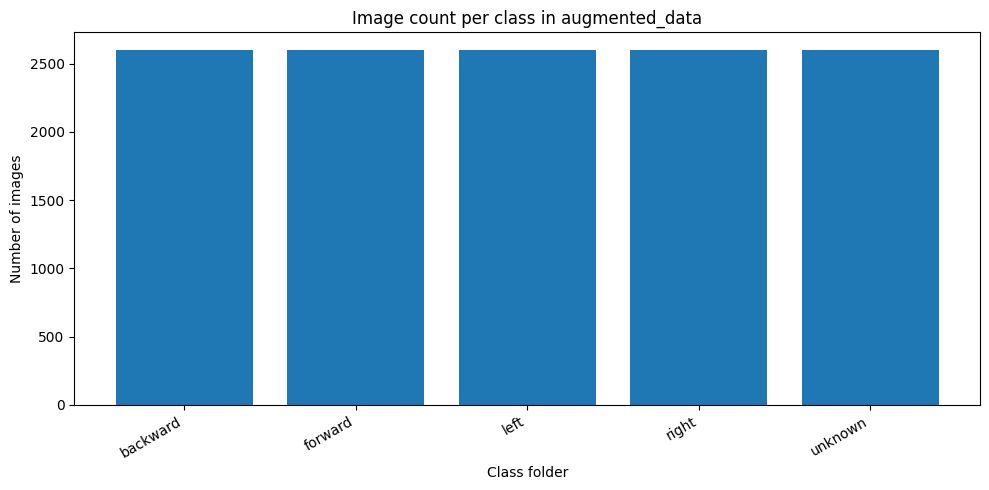

In [5]:
from __future__ import annotations

from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt

# -------- CONFIG --------
DATA_ROOT = Path("augmented_data")
# If None, auto-detect subfolders
CLASSES = None  # e.g. ["forward", "backward", "left", "right", "unknown"]

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
RECURSIVE = False  # set True if your class folders have nested folders


def count_images(folder: Path) -> int:
    if not folder.exists() or not folder.is_dir():
        return 0
    it = folder.rglob("*") if RECURSIVE else folder.iterdir()
    return sum(
        1 for p in it
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    )


def main() -> None:
    if not DATA_ROOT.exists():
        raise FileNotFoundError(f"Folder not found: {DATA_ROOT.resolve()}")

    if CLASSES is None:
        classes = sorted([p.name for p in DATA_ROOT.iterdir() if p.is_dir()])
    else:
        classes = CLASSES

    if not classes:
        raise RuntimeError(f"No subfolders found in: {DATA_ROOT.resolve()}")

    counts = {cls: count_images(DATA_ROOT / cls) for cls in classes}

    print("Image counts:")
    for cls in classes:
        print(f"  {cls:10s}: {counts[cls]}")

    # ---- Plot bar chart ----
    plt.figure(figsize=(10, 5))
    plt.bar(list(counts.keys()), list(counts.values()))
    plt.title("Image count per class in augmented_data")
    plt.xlabel("Class folder")
    plt.ylabel("Number of images")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ryanbijujoseph/hand-gesture-dataset")

print("Path to dataset files:", path)